# Import Library

In [ ]:
import torch
import numpy as np
import pandas as pd
from unsloth import FastLanguageModel
from datasets import Dataset
from trl import SFTTrainer
from transformers import TrainingArguments
from sklearn.metrics import average_precision_score, roc_auc_score, precision_recall_curve
import matplotlib.pyplot as plt

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!


# Load Dataset

In [ ]:
# Load dataset
DATASET_PATH = "/content/drive/MyDrive/INTERN INFOMEDIA/preprocessed_no_resample.csv"
df = pd.read_csv(DATASET_PATH)
print(f"\n📊 STATISTIK DATASET:")
print(f"   Total records: {len(df)}")

# Cek distribusi label
class_0_count = len(df[df['incident'] == 0])
class_1_count = len(df[df['incident'] == 1])
total = class_0_count + class_1_count

print(f"\n📈 DISTRIBUSI LABEL:")
print(f"   Class 0 (Tidak Butuh Maintenance): {class_0_count} ({class_0_count/total*100:.1f}%)")
print(f"   Class 1 (Butuh Maintenance): {class_1_count} ({class_1_count/total*100:.1f}%)")
print(f"   Ratio Class0:Class1 = {class_0_count/class_1_count:.2f}:1")


📊 STATISTIK DATASET:
   Total records: 18969

📈 DISTRIBUSI LABEL:
   Class 0 (Tidak Butuh Maintenance): 11136 (58.7%)
   Class 1 (Butuh Maintenance): 7833 (41.3%)
   Ratio Class0:Class1 = 1.42:1


In [ ]:
df.head()

,Timestamp,Impact,Priority,incident
0,2024-01-01 08:13:45,2,2,1
1,2024-01-10 15:06:49,2,2,1
2,2024-01-05 06:11:00,1,1,0
3,2024-01-10 14:19:44,1,1,0
4,2024-01-10 14:02:29,1,1,0


In [ ]:
print("\nValue Distribution for 'Impact' column:")
display(df['Impact'].value_counts())

print("\nValue Distribution for 'Priority' column:")
display(df['Priority'].value_counts())


Value Distribution for 'Impact' column:


,count
Impact,
1,10111
2,7903
3,812
4,143



Value Distribution for 'Priority' column:


,count
Priority,
1,10471
2,6832
3,1504
4,162


# Data Preprocessing

In [ ]:
# Sort by Timestamp to preserve causal order
df = df.sort_values('Timestamp').reset_index(drop=True)
df.head()

,Timestamp,Impact,Priority,incident
0,2023-12-31 23:53:29,2,2,1
1,2024-01-01 01:46:13,2,2,1
2,2024-01-01 02:29:38,2,2,1
3,2024-01-01 05:13:42,2,2,1
4,2024-01-01 05:56:32,1,1,0


In [ ]:
# ==========================================
# SLIDING WINDOW SERIALIZATION
# ==========================================

window_size = 48
feature_cols = ['Priority', 'Impact']

prompt_template = """### Instruction:
Analyze the system log history and forecast if a failure will occur in the next step.

### Input:
{history}

### Response:
{label}"""

def create_llm_windows(dataframe, window_size):
    processed_samples = []

    # Iterate through the timeline
    for i in range(len(dataframe) - window_size):
        # 1. Grab the Window (The History)
        # We take rows i to i+window_size
        window_df = dataframe.iloc[i : i + window_size]

        # 2. Serialize History into Text
        # Format: "T-2: Prio=1.0 | T-1: Prio=2.5 | T-0: Prio=3.0"
        history_text = []
        for step, (_, row) in enumerate(window_df.iterrows()):
            time_label = f"T-{window_size - step}" # e.g., T-6, T-5...

            # Create a dense string for this specific timestamp
            step_features = f"{time_label}: Prio={row['Priority']:.1f}, Imp={row['Impact']:.1f}" # Removed PrioAvg
            history_text.append(step_features)

        # Join with newlines for clarity
        full_history = "\n".join(history_text)

        # 3. Grab the Target (The Future)
        # We predict the NEXT step (i + window_size)
        target_row = dataframe.iloc[i + window_size]
        label = "Incident" if target_row['incident'] == 1 else "Normal"

        # 4. Compile
        text = prompt_template.format(history=full_history, label=label)
        processed_samples.append(text)

    return processed_samples

print(f"creating sliding windows (Size={window_size})...")
llm_data = create_llm_windows(df, window_size)

# Convert to HuggingFace Dataset
full_dataset = Dataset.from_dict({"text": llm_data})

# Time-Series Split (Train on past, Test on future)
split_idx = int(len(full_dataset) * 0.85)
train_dataset = full_dataset.select(range(split_idx))
eval_dataset = full_dataset.select(range(split_idx, len(full_dataset)))

print(f"Samples Generated: {len(full_dataset)}")
print(f"Example Prompt:\n{train_dataset[0]['text'].split('### Response')}")


creating sliding windows (Size=48)...
Samples Generated: 18921
Example Prompt:
['### Instruction:\nAnalyze the system log history and forecast if a failure will occur in the next step.\n\n### Input:\nT-48: Prio=2.0, Imp=2.0\nT-47: Prio=2.0, Imp=2.0\nT-46: Prio=2.0, Imp=2.0\nT-45: Prio=2.0, Imp=2.0\nT-44: Prio=1.0, Imp=1.0\nT-43: Prio=1.0, Imp=1.0\nT-42: Prio=1.0, Imp=1.0\nT-41: Prio=1.0, Imp=1.0\nT-40: Prio=1.0, Imp=1.0\nT-39: Prio=2.0, Imp=2.0\nT-38: Prio=2.0, Imp=2.0\nT-37: Prio=1.0, Imp=1.0\nT-36: Prio=2.0, Imp=2.0\nT-35: Prio=2.0, Imp=2.0\nT-34: Prio=2.0, Imp=2.0\nT-33: Prio=2.0, Imp=2.0\nT-32: Prio=2.0, Imp=2.0\nT-31: Prio=2.0, Imp=1.0\nT-30: Prio=2.0, Imp=2.0\nT-29: Prio=2.0, Imp=2.0\nT-28: Prio=1.0, Imp=1.0\nT-27: Prio=2.0, Imp=2.0\nT-26: Prio=3.0, Imp=3.0\nT-25: Prio=2.0, Imp=2.0\nT-24: Prio=1.0, Imp=1.0\nT-23: Prio=1.0, Imp=1.0\nT-22: Prio=1.0, Imp=1.0\nT-21: Prio=2.0, Imp=2.0\nT-20: Prio=2.0, Imp=2.0\nT-19: Prio=1.0, Imp=1.0\nT-18: Prio=2.0, Imp=2.0\nT-17: Prio=2.0, Imp=2.0\n

# Model Configuration

In [ ]:
model_name = "unsloth/SmolLM2-135M-Instruct-bnb-4bit"

print(f"🚀 Loading {model_name}...")
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = model_name,
    max_seq_length = 2048, # Maximum token. Needs more context for history windows
    dtype = None,
    load_in_4bit = False,
)

# LoRA adapter
model = FastLanguageModel.get_peft_model(
    model,
    r = 16,
    target_modules = ["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
    lora_alpha = 16,
    lora_dropout = 0,
    bias = "none",
    use_gradient_checkpointing = "unsloth",
)

🚀 Loading unsloth/SmolLM2-135M-Instruct-bnb-4bit...
==((====))==  Unsloth 2026.1.4: Fast Llama patching. Transformers: 4.57.6.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.741 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.9.0+cu126. CUDA: 7.5. CUDA Toolkit: 12.6. Triton: 3.5.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


# Fine Tuning

In [ ]:
training_args = TrainingArguments(
    per_device_train_batch_size = 4, # Smaller batch due to longer window prompts
    gradient_accumulation_steps = 4,
    warmup_steps = 10,
    num_train_epochs = 1,
    learning_rate = 2e-4,
    fp16 = not torch.cuda.is_bf16_supported(),
    bf16 = torch.cuda.is_bf16_supported(),
    logging_steps = 100,
    optim = "adamw_8bit", # Adam Optimizer
    weight_decay = 0.01,
    lr_scheduler_type = "linear",
    seed = 3407,
    output_dir = "outputs",
    report_to = "none", # Disable Weights & Biases reporting
)

trainer = SFTTrainer(
    model = model,
    tokenizer = tokenizer,
    train_dataset = train_dataset,
    dataset_text_field = "text",
    max_seq_length = 2048,
    args = training_args,
)

trainer.train()

Unsloth: We found double BOS tokens - we shall remove one automatically.


Unsloth: Tokenizing ["text"] (num_proc=4):   0%|          | 0/16082 [00:00<?, ? examples/s]

The model is already on multiple devices. Skipping the move to device specified in `args`.
==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 16,082 | Num Epochs = 1 | Total steps = 1,006
O^O/ \_/ \    Batch size per device = 4 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (4 x 4 x 1) = 16
 "-____-"     Trainable parameters = 4,884,480 of 139,400,064 (3.50% trained)


Step,Training Loss
100,0.138500
200,0.071400
300,0.071700
400,0.071200
500,0.070700
600,0.070100
700,0.070500
800,0.070700
900,0.070500
1000,0.070700


TrainOutput(global_step=1006, training_loss=0.07754988426242623, metrics={'train_runtime': 2794.147, 'train_samples_per_second': 5.756, 'train_steps_per_second': 0.36, 'total_flos': 9538703373680640.0, 'train_loss': 0.07754988426242623, 'epoch': 1.0})

# Evaluation


🔮 Running Forecast Evaluation...


100%|██████████| 178/178 [04:21<00:00,  1.47s/it]


--- Classification Report ---
              precision    recall  f1-score   support

      Normal       0.58      1.00      0.73      1643
    Incident       0.46      0.01      0.01      1196

    accuracy                           0.58      2839
   macro avg       0.52      0.50      0.37      2839
weighted avg       0.53      0.58      0.43      2839


ROC-AUC Score: 0.5340
PR-AUC Score: 0.4495


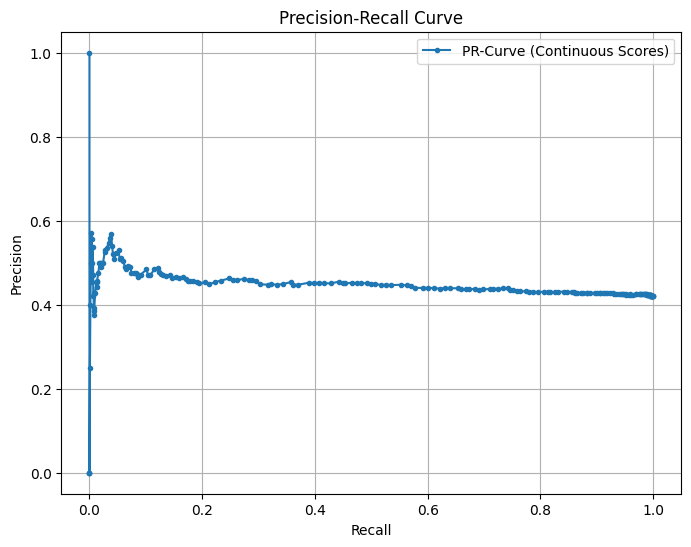

In [ ]:
import torch.nn.functional as F

print("\n🔮 Running Forecast Evaluation...")
FastLanguageModel.for_inference(model)

test_prompts = [row['text'].split("### Response:\n")[0] + "### Response:\n" for row in eval_dataset]
actuals = [1 if "Incident" in row['text'] else 0 for row in eval_dataset]
predictions = []
incident_prediction_scores = [] # Stores continuous scores for ROC/PR curves

from tqdm import tqdm
from sklearn.metrics import classification_report, roc_auc_score, average_precision_score, precision_recall_curve
import matplotlib.pyplot as plt

batch_size = 16

# Get token IDs for ' Incident' and ' Normal' (with leading space as typically generated)
incident_first_token_id = tokenizer.encode(" Incident", add_special_tokens=False)[0]
normal_first_token_id = tokenizer.encode(" Normal", add_special_tokens=False)[0]

for i in tqdm(range(0, len(test_prompts), batch_size)):
    batch = test_prompts[i:i+batch_size]
    inputs = tokenizer(batch, return_tensors="pt", padding=True).to("cuda")

    with torch.no_grad():
        outputs_generate = model.generate(
            **inputs,
            max_new_tokens=4, # Generate up to 4 tokens as before for hard predictions
            output_scores=True, # Request logits for generated tokens
            return_dict_in_generate=True, # Return outputs as a dictionary
            use_cache=True,
            pad_token_id=tokenizer.eos_token_id # Important for handling padded sequences
        )

    decoded = tokenizer.batch_decode(outputs_generate.sequences, skip_special_tokens=True)

    # Logits for the *first* generated token in the response
    first_token_logits_batch = outputs_generate.scores[0] # Shape (batch_size, vocab_size)

    for j, text in enumerate(decoded):
        # Hard prediction logic (for classification report)
        response_part = text.split("### Response:\n")[-1]
        if "Incident" in response_part:
            predictions.append(1)
        else:
            predictions.append(0)

        # Soft prediction logic (for ROC/PR curves)
        # Get the logits for the first token of 'Incident' and 'Normal'
        logit_incident_start = first_token_logits_batch[j, incident_first_token_id].item()
        logit_normal_start = first_token_logits_batch[j, normal_first_token_id].item()

        # Use the difference in logits as a continuous score for the positive class (Incident)
        # A higher score indicates a higher likelihood of 'Incident'
        score_for_incident = logit_incident_start - logit_normal_start
        incident_prediction_scores.append(score_for_incident)

print("\n--- Classification Report ---")
print(classification_report(actuals, predictions, target_names=["Normal", "Incident"]))

# --- Add ROC-AUC and PR-AUC Metrics with continuous scores ---
# Calculate ROC-AUC Score
roc_auc = roc_auc_score(actuals, incident_prediction_scores)
print(f"\nROC-AUC Score: {roc_auc:.4f}")

# Calculate PR-AUC Score (Average Precision Score)
pr_auc = average_precision_score(actuals, incident_prediction_scores)
print(f"PR-AUC Score: {pr_auc:.4f}")

# Plotting Precision-Recall Curve
precision, recall, _ = precision_recall_curve(actuals, incident_prediction_scores)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, marker='.', label='PR-Curve (Continuous Scores)')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid(True)
plt.show()